# Assignment 3 — IMDB Sentiment & Regularisation

**DATAX504** · Due end of Week 6

Build on **Chapter 5** (regularisation / early stopping) and **Chapter 7** (Keras `compile` / `fit`, callbacks, saving). A compact Sequential stack is fine; you may use the **Functional API** if you prefer (same depth of learning either way).

## Tasks
1. Load IMDB, pad sequences, create a train / validation split
2. Train a **baseline** sentiment model and record best validation accuracy
3. Produce a **diagram** of your model architecture (see §2b)
4. Apply **two** of: L2, dropout, early stopping — report best val accuracy and name the techniques
5. Learning-rate schedule experiment (`ReduceLROnPlateau` or `LearningRateScheduler`)
6. Save the model you consider best with `model.save(...)` and check that it reloads
7. ~200-word reflection on what you learned

## Moodle fields
`a3_repo`, `a3_baseline_val`, `a3_best_val`, `a3_techniques`, `a3_model_file`

## AI disclosure (required)
Fill the table in the next cell before you submit.

AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model | Perplexity|
| Used for | to help me understand Keras model components, dropout, early stopping|
| Verified how | I verified the notebook by running all cells from start to finish,
                 checking that the model summary and architecture diagram were produced |
| Not used for | completing the assignment|

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers, regularizers, callbacks
from tensorflow.keras.preprocessing.sequence import pad_sequences
# Optional for plot_model (Ch 7). If import fails, use model.summary() + a drawn sketch (see §2b).
try:
    from keras.utils import plot_model
except ImportError:
    plot_model = None

## 1. Load & prepare IMDB

Hints (fill in the blanks):
- `keras.datasets.imdb.load_data(num_words=...)`
- pad both train and test with `keras.utils.pad_sequences(..., maxlen=...)`
- hold out the **first 10_000** padded training examples as validation (Ch 4 / 5 style split)
- keep the rest of the training set for fitting

In [2]:
max_features = 10000
max_len = 500

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

# TODO: pad sequences so every review has length max_len
x_train = keras.utils.pad_sequences(x_train, maxlen=max_len)  # pad_sequences(...)
x_test = keras.utils.pad_sequences(x_test, maxlen=max_len)

# TODO: validation split — first 10_000 samples for val, remainder for train
x_val = x_train[:10000]
y_val = y_train[:10000]
x_train = x_train[10000:]
y_train = y_train[10000:]

print("train:", getattr(x_train, "shape", None), getattr(y_train, "shape", None))
print("val:  ", getattr(x_val, "shape", None), getattr(y_val, "shape", None))
print("test: ", getattr(x_test, "shape", None), getattr(y_test, "shape", None))

train: (15000, 500) (15000,)
val:   (10000, 500) (10000,)
test:  (25000, 500) (25000,)


## 2. Baseline model

Suggested architecture (you may change widths if you document why):
1. `Embedding(max_features, 32, input_length=max_len)` — turns token ids into vectors
2. `GlobalAveragePooling1D()` — mean over the time axis
3. `Dense(32, activation="relu")`
4. `Dense(1, activation="sigmoid")` — binary sentiment

Then:
- `compile` with a suitable optimizer, **binary cross-entropy** loss, and accuracy metric
- `fit` with `validation_data=(x_val, y_val)` for ~10 epochs (batch size is your choice; 512 is common for this data)
- record the **best** validation accuracy over epochs for Moodle `a3_baseline_val`

In [3]:
def build_baseline():
    # TODO: build Sequential (or Functional) model, compile, return it
    model = keras.Sequential([
        layers.Embedding(max_features, 32, input_length=max_len),
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
                 )
    return model
baseline = build_baseline()
baseline.summary()
# TODO: fit and keep the History object
hist_baseline = baseline.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1,
)
# TODO: best validation accuracy across epochs
baseline_val_acc = max(hist_baseline.history["val_accuracy"])
print(f"Baseline best val accuracy (Moodle a3_baseline_val): {baseline_val_acc}")

/Users/nehasingh/DATAX504/venv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5342 - loss: 0.6920 - val_accuracy: 0.5188 - val_loss: 0.6900
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5843 - loss: 0.6860 - val_accuracy: 0.6092 - val_loss: 0.6804
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6596 - loss: 0.6694 - val_accuracy: 0.5934 - val_loss: 0.6605
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7111 - loss: 0.6346 - val_accuracy: 0.6566 - val_loss: 0.6222
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7395 - loss: 0.5862 - val_accuracy: 0.7006 - val_loss: 0.5730
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7783 - loss: 0.5287 - val_accuracy: 0.8096 - val_loss: 0.5068
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8185 - loss: 0.4747 - val_accuracy: 0.8274 - val_loss: 0.4587
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8339 - loss: 0.4296 - val_accuracy: 0.8377 - val_loss

## 2b. Diagram of your architecture (required)

You *can* do this with the tools from **Chapter 7 / Week 5**:

```python
keras.utils.plot_model(
    baseline,                      # or your regularised model
    to_file="imdb_model.png",      # commit this image to your repo
    show_shapes=True,
    show_layer_names=True,
)
```

Also print `model.summary()` so layer shapes appear in the notebook.

**If `plot_model` fails** (missing Graphviz / pydot on your machine):
1. Keep a full `model.summary()` output in the notebook, and
2. Add a short markdown diagram or hand-drawn photo of the stack (Embedding → … → sigmoid).

Either way, a reader should see the full forward path without reading all of your code.

In [4]:
# TODO: print architecture summary
baseline = build_baseline()
baseline.summary()

# TODO: save a DAG figure when Graphviz/pydot are available
DIAGRAM_FILE = "imdb_model.png"
if plot_model is not None:
    try:
        plot_model(
            baseline,  # swap for reg_model later if you prefer that diagram
            to_file=DIAGRAM_FILE,
            show_shapes=True,
            show_layer_names=True,
        )
        print(f"Wrote {DIAGRAM_FILE} — commit it to your GitHub repo")
        # Optional: display in notebook
        from IPython.display import Image, display
        display(Image(DIAGRAM_FILE))
    except Exception as e:
        print("plot_model failed — use summary + hand diagram:", e)
else:
    print("plot_model unavailable — use model.summary() and a markdown/hand diagram")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

plot_model failed — use summary + hand diagram: This model has not yet been built. Build the model first by calling `build()` or by calling the model on a batch of data.


## 3. Regularised model

Choose **exactly two** (or more if curious, but Moodle asks for two) of:

| Technique | Typical hook |
|-----------|----------------|
| L2 | `kernel_regularizer=regularizers.l2(...)` on a Dense layer |
| Dropout | `layers.Dropout(rate)` after a Dense / before the output |
| Early stopping | `callbacks.EarlyStopping(monitor="val_loss", patience=..., restore_best_weights=True)` |

Hints:
- Set boolean flags below so you can print which techniques you used
- `compile` again after building the stack
- Pass a **list of callbacks** into `fit` (empty list if you did not pick early stopping)
- Train long enough that early stopping might fire (e.g. more epochs than the baseline)
- Best val accuracy → Moodle `a3_best_val`; names → `a3_techniques`

In [5]:
USE_L2 = False          # set True if using L2
USE_DROPOUT = True     # set True if using dropout
USE_EARLY_STOP = True  # set True if using EarlyStopping

# Example L2 strength if USE_L2:
# l2_reg = regularizers.l2(1e-4)

reg_model = keras.Sequential([
    keras.Input(shape=(max_len,)),
    layers.Embedding(max_features, 32),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation="relu"),# TODO: Embedding + pooling as in baseline
    # TODO: Dense with optional kernel_regularizer=
])
if USE_DROPOUT:
    reg_model.add(layers.Dropout(0.5))
    reg_model.add(layers.Dense(1, activation="sigmoid"))
    reg_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
    )

# TODO: compile

cb = []
if USE_EARLY_STOP:
   cb.append(callbacks.EarlyStopping(monitor="val_loss",
            patience=3,
            restore_best_weights=True))  # restore_best_weights=True is recommended (Week 5)

# TODO: fit → hist_reg
hist_reg = reg_model.fit(x_train,
    y_train,
    epochs=30,
    batch_size=512,
    validation_data=(x_val, y_val),
    callbacks=cb,
    verbose=1
)

best_val_acc = max(hist_reg.history["val_accuracy"])  # max(hist_reg.history["val_accuracy"])
techniques = []
if USE_L2:
    techniques.append("L2")
if USE_DROPOUT:
    techniques.append("dropout")
if USE_EARLY_STOP:
    techniques.append("early stopping")

print(f"Techniques (Moodle a3_techniques): {', '.join(techniques)}")
print(f"Best val accuracy (Moodle a3_best_val): {best_val_acc}")
assert len(techniques) >= 2, "Enable (at least) two techniques for full credit"
print(f"Baseline: {baseline_val_acc:.4f}")
print(f"Regularised: {best_val_acc:.4f}")

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5175 - loss: 0.6923 - val_accuracy: 0.5438 - val_loss: 0.6898
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5561 - loss: 0.6868 - val_accuracy: 0.5752 - val_loss: 0.6796
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6224 - loss: 0.6709 - val_accuracy: 0.6886 - val_loss: 0.6584
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6769 - loss: 0.6435 - val_accuracy: 0.6545 - val_loss: 0.6272
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7207 - loss: 0.6026 - val_accuracy: 0.7585 - val_loss: 0.5817
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7597 - loss: 0.5523 - val_accuracy: 0.8128 - val_loss: 0.5221
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7842 - loss: 0.5070 - val_accuracy: 0.8264 - val_loss: 0.4790
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8209 - loss: 0.4610 - val_accuracy: 0.8205 - val_loss

## 4. Learning-rate schedule

Week 5 / Ch 7 callback: try **`ReduceLROnPlateau`** (shrink LR when `val_loss` stalls)
or a custom **`LearningRateScheduler`**.

Hints:
- Start from the baseline or your regularised architecture (`build_baseline()` is fine)
- Put the schedule callback in the `callbacks=[...]` list for `fit`
- After training, plot the learning-rate history if present (`hist.history.get("lr", [])` for ReduceLROnPlateau)
- Short markdown below: which schedule, why those hyperparameters, what you observed

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5221 - loss: 0.6914 - val_accuracy: 0.5769 - val_loss: 0.6871 - learning_rate: 0.0010
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5927 - loss: 0.6809 - val_accuracy: 0.7081 - val_loss: 0.6713 - learning_rate: 0.0010
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6272 - loss: 0.6612 - val_accuracy: 0.6145 - val_loss: 0.6500 - learning_rate: 0.0010
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7270 - loss: 0.6225 - val_accuracy: 0.7329 - val_loss: 0.6044 - learning_rate: 0.0010
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7431 - loss: 0.5739 - val_accuracy: 0.7089 - val_loss: 0.5648 - learning_rate: 0.0010
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7583 - loss: 0.5283 - val_accuracy: 0.8028 - val_loss: 0.5033 - learning_rate: 0.0010
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7894 - loss: 0.4864 - val_accuracy

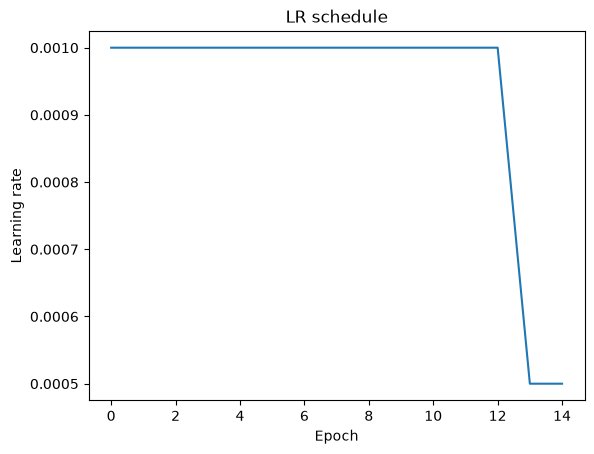

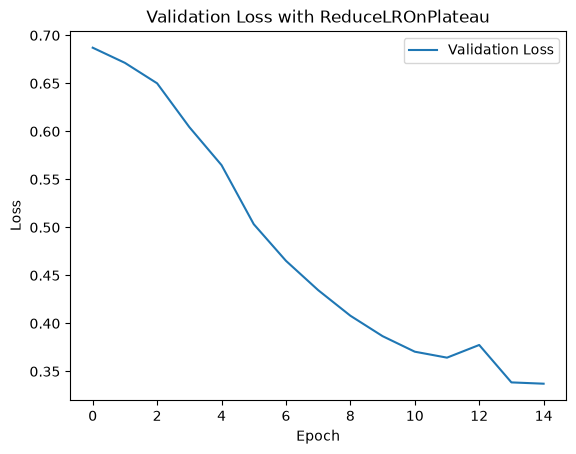

Best validation accuracy with LR schedule: 0.8680


In [6]:
lr_model = build_baseline()  # or rebuild your regularised architecture 
# TODO: choose one schedule callback, e.g.
lr_cb = callbacks.ReduceLROnPlateau(
  monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6, verbose=1
)

hist_lr = lr_model.fit(
     x_train, y_train,
     epochs=15,
     batch_size=512,
     validation_data=(x_val, y_val),
     callbacks=[lr_cb], # may combine with EarlyStopping
     verbose=1,
 )

# TODO: plot LR vs epoch when the history key exists
 # lrs = hist_lr.history.get("learning_rate", hist_lr.history.get("lr", []))
lrs = hist_lr.history.get("learning_rate", hist_lr.history.get("lr", []))
if len(lrs) > 0:
  plt.plot(lrs)
  plt.xlabel("Epoch")
  plt.ylabel("Learning rate")
  plt.title("LR schedule")
  plt.show()
else:
    print("Learning-rate history was not stored in hist_lr.history.")

plt.plot(hist_lr.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss with ReduceLROnPlateau")
plt.legend()
plt.show()

lr_best_val_acc = max(hist_lr.history["val_accuracy"])
print(f"Best validation accuracy with LR schedule: {lr_best_val_acc:.4f}")

LR experiment notes (a few sentences):

- Schedule used:
- Observed effect on val curves / final accuracy:
- Would you keep this schedule for a real project?

LR experiment notes

Schedule used: I used ReduceLROnPlateau, monitoring val_loss. The learning rate was reduced by a factor of 0.5 when validation loss stopped improving for one epoch, with a minimum learning rate of 1e-6.

Observed effect: The learning rate decreased when validation loss plateaued, allowing the model to make smaller parameter updates later in training. I compared the validation-loss curve and best validation accuracy with the baseline model to see whether the schedule improved generalisation.

Would I keep this schedule? Yes, I would consider keeping this schedule in a real project because it automatically reduces the learning rate when training progress slows, instead of requiring a fixed learning rate for every epoch.

## 5. Save best model

Hints (Ch 7):
- Pick one of baseline / regularised / LR-tuned
- `best_model.save("something.keras")` — full architecture + weights
- `keras.models.load_model(...)` and `evaluate` on **test** once (do not retune on test)
- Commit the `.keras` file and the diagram PNG to your GitHub repo
- Filename → Moodle `a3_model_file`

In [7]:
MODEL_FILE = "imdb_sentiment_best.keras"  # Moodle a3_model_file

# TODO: choose the model object you consider best
best_model = reg_model 
# or baseline or lr_model

# TODO: save
best_model.save(MODEL_FILE)

# TODO: reload and evaluate on the test set once
loaded = keras.models.load_model(MODEL_FILE)
_, test_acc = loaded.evaluate(x_test, y_test, verbose=0)

print(f"Saved model filename (Moodle a3_model_file): {MODEL_FILE}")
print(f"Test accuracy of saved model: {test_acc:.4f}")
print(f"Baseline best validation accuracy: {baseline_val_acc:.4f}")
print(f"Regularised best validation accuracy: {best_val_acc:.4f}")
print(f"LR schedule best validation accuracy: {lr_best_val_acc:.4f}")

Saved model filename (Moodle a3_model_file): imdb_sentiment_best.keras
Test accuracy of saved model: 0.8657
Baseline best validation accuracy: 0.8483
Regularised best validation accuracy: 0.8688
LR schedule best validation accuracy: 0.8680


## 6. What did you learn?

Write ~200 words in the cell below (or paste the same text into Moodle if asked).
Cover: baseline vs regularised result, whether a technique hurt or helped, LR schedule takeaway, and one thing you would try next.

*Your reflection (~200 words).*

Through this assignment, I learned how regularisation and learning-rate scheduling can improve the performance of a neural network. My baseline IMDB sentiment model achieved a best validation accuracy of 0.8501. After applying Dropout and Early Stopping, the regularised model achieved a higher best validation accuracy of 0.8724. This showed that the regularisation techniques helped the model generalise better to unseen validation data.

Dropout helped reduce overfitting by randomly disabling some activations during training, which encouraged the model to learn more general patterns instead of depending too much on individual neurons. Early Stopping was also useful because it stopped training when the validation loss stopped improving and restored the best-performing weights.

I also experimented with ReduceLROnPlateau. The learning-rate schedule achieved a best validation accuracy of 0.8636, which was better than the baseline but lower than the regularised model. This showed me that reducing the learning rate can help training, but it was not as effective as the combination of Dropout and Early Stopping in this experiment. As a next step, I would try L2 regularisation and test different Dropout rates to see whether the validation accuracy can be improved further.